# **LPC project - Game of Life**

Andrea Santarossa, 
Francesco Pazzocco, 
Manjodh Singh,
Niccolò Bellocci

Conway's Game of Life is a cellular automaton devised by mathematician John Conway in 1970. It is a zero-player game, meaning that its progression is determined by its initial state, with no further input from players during the evolution of the system. The game consists of a grid of cells, each of which can be in one of two states: alive or dead. We have found it interesting because of the observations of complex patterns that could may emerge from the implementation of very simple rules.

The basic rules are:
- Birth: A dead cell becomes alive if it has exactly three live neighbors.
- Survival: A live cell stays alive if it has two or three live neighbors.
- Death: A live cell dies if it has fewer than two or more than three live neighbors (underpopulation or overpopulation).
- The state of the grid evolves in discrete time intervals, so all the cells are being updated/evolved simultaneously each time step, which is the passing of a generation.  

The state of each cell in the next generation is determined by its current state and the number of live neighbors surrounding it.

IN QUESTO NOTEBOOK PRESENTEREMO:
- BASIC IMPLEMENTATION
- EVOLUTION OF KNOWN PATTERNS
- ANALYSIS
- THE HIERARCHICAL VERSION OF THE GAME

## Basic Game of Life

We start by building the basic version of the Game of Life. The user can choose the size of the grid and the number of generations for the game to evolve. The initial configuration of the cells is randomly generated.

In [2]:
import numpy as np
from scipy.ndimage import convolve
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
import copy
import matplotlib.colors as mcolors

A `FILTER` used by the convolve function from the `scipy.ndimage` module to count the number of living neighbors around each cell. It is a 3x3 array used in the `NextStep` function to apply the rules of the Game of Life.

In [3]:
FILTER = np.array([[1, 1, 1],
                   [1, 20, 1],
                   [1, 1, 1]], dtype=np.uint8)

In [4]:
cmap = mcolors.ListedColormap([(1, 1, 1, 0), (0, 0, 0, 1)])  # 0 -> transparent, 1 -> black
bounds = [0, 0.5, 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

The `PlotGrid_basic` function is a visualization tool for Conway's Game of Life. It displays the current state of the grid, highlighting alive and dead cells, and incorporates custom styling, including adjustable gridlines and thick borders around the grid.

In [5]:
def PlotGrid_basic(grid, ax, fig, fine_spacing=1, t=0):
    
    ax.clear()
    ax.imshow(grid, cmap=cmap, norm=norm, interpolation='nearest', extent=[0, grid.shape[1], 0, grid.shape[0]])

    # Gridlines
    ax.set_xticks(np.arange(0, grid.shape[1], fine_spacing), minor=True)
    ax.set_yticks(np.arange(0, grid.shape[0], fine_spacing), minor=True)
    ax.grid(which="minor", color="gray", linestyle='-', linewidth=1, alpha=0.7)
    ax.set_title("Game of Life: T="+str(t))
    
    # Add thick borders
    for spine in ax.spines.values():
        spine.set_linewidth(2)  
        spine.set_edgecolor("black")  
    
    # Remove axis ticks
    ax.tick_params(axis='both', which='both', length=0)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0, grid.shape[0])
    ax.set_ylim(0, grid.shape[1])
    
    # Display in Jupyter Notebook
    clear_output(wait=True)
    display(fig)
    time.sleep(0)

The `NextStep` function computes the next state on its current configuration. It applies the game's rules using a convolution operation to efficiently count neighbors and determine the survival or birth of cells.

In [6]:
def NextStep(current, next):
    next[:] = 0
    count = convolve(current, FILTER, mode="wrap")
    next[(count == 3) | (count == 22) | (count == 23)] = 1
    return next

The `evolve_basic` function is the core simulation driver for Conway's Game of Life. It initializes a random starting configuration for the grid, then iteratively evolves the grid according to the rules of the game for a specified number of generations.

In [7]:
def evolve_basic(length, T):
    
    # Initialize the universe
    current = np.random.randint(2, size=(length, length))
    next = np.empty_like(current)

    # Set up the figure and axis
    fig, ax = plt.subplots(figsize=(6, 6))

    # Run the simulation for the given number of generations
    for t in range(1,T+1):
        next = NextStep(current, next)
        current, next = next, current
        PlotGrid_basic(current, ax, fig,t=t)

    plt.close(fig) # Close the figure when done

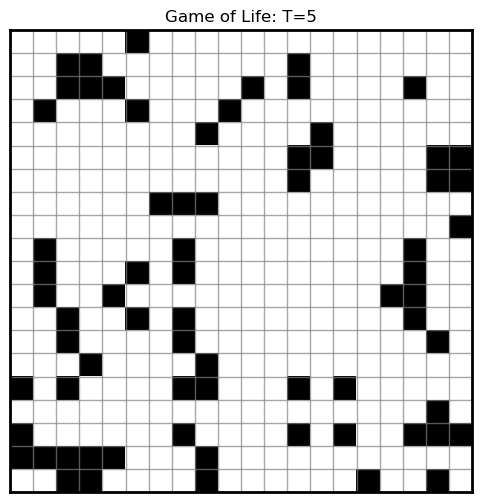

In [8]:
# Length = dimension of the grid
# T = time steps
evolve_basic(length=20, T=5) 

## Play with advanced pattern

In this section, we explore predefined patterns in Conway’s Game of Life. These patterns exhibit unique behaviors and can be classified into different categories:

 - **Still Life**: Patterns that remain static, such as block, beehive, loaf, and boat.
 - **Oscillators**: Patterns that cycle through a set of states, including blinker, toad, beacon, and pulsar.
 - **Spaceships**: Moving patterns that travel across the grid, like the glider, lightweight spaceship (LWSS), middleweight spaceship (MWSS), and heavyweight spaceship (HWSS).
 - **Methuselahs**: Small patterns that evolve for a long time before stabilizing, such as R-pentomino, diehard, and acorn.
 - **Guns and Engines**: Patterns that generate other moving structures, including Gosper glider gun and switch engine.
 
These patterns can be fetched from an online repository and integrated into our simulation.

In [9]:
patterns = [
    # Oscillators
    "clock",
    "pulsar",
    "pentadecathlon",
    "blinker",
    "toad",
    "beacon",
    "glider",
    
    # Spaceships
    "lwss",  # Lightweight Spaceship
    "mwss",  # Middleweight Spaceship
    "hwss",  # Heavyweight Spaceship
    
    # Guns
    "gosperglidergun",
    "simkinglidergun",
    
    # Still Life
    "block",
    "beehive",
    "loaf",
    "boat",
    "tub",
    
    # Methuselahs
    "r-pentomino",
    "diehard",
    "acorn",
    
    # Engines
    "switchengine"]

The `initial_state` function generates an initial grid for Game of Life. It supports both randomly generated states and predefined patterns retrieved from an online database.

In [10]:
import requests
import re

def initial_state(length, pattern_name="random", config_param=0.5, return_Pattern=False):
    # Base URL for fetching patterns
    if pattern_name.lower()=="random":
        p = config_param
        grid = np.random.choice([0,1],p=[1-p,p], size=(length, length))
        return grid
    base_url = f"https://conwaylife.com/patterns/{pattern_name}.rle"

    try:
        response = requests.get(base_url)
        response.raise_for_status()
        rle_data = response.text
    except requests.RequestException as e:
        raise ValueError(f"Error: '{pattern_name}': {e}")

    # Parse the RLE file to extract pattern dimensions and content
    pattern_lines = []
    x_size, y_size = None, None
    for line in rle_data.splitlines():
        if line.startswith("#") or line.strip() == "":
            continue
        if line.startswith("x ="):
            match = re.search(r"x = (\d+), y = (\d+)", line)
            if match:
                x_size, y_size = int(match.group(1)), int(match.group(2))
        else:
            pattern_lines.append(line)

    if x_size is None or y_size is None:
        raise ValueError(f"Invalid RLE file format for pattern '{pattern_name}'.")

    pattern_grid = np.zeros((y_size, x_size), dtype=int)
    x, y = 0, 0
    for line in pattern_lines:
        count = ""
        for char in line:
            if char.isdigit():
                count += char
            elif char == "b":  # Dead cells
                count = int(count) if count else 1
                pattern_grid[y, x:x + count] = 0
                x += count
                count = ""
            elif char == "o":  # Alive cells
                count = int(count) if count else 1
                pattern_grid[y, x:x + count] = 1
                x += count
                count = ""
            elif char == "$":  # End of row
                count = int(count) if count else 1
                y += count
                x = 0
                count = ""
            elif char == "!":  # End of pattern
                break
    if return_Pattern == True:
        return pattern_grid
    
    # Center the pattern in the grid
    grid = np.zeros((length, length), dtype=int)
    start_x = (length - x_size) // 2
    start_y = (length - y_size) // 2
    grid[start_y:start_y + y_size, start_x:start_x + x_size] = pattern_grid

    return grid

The `evolve` function is an enhanced version of `evolve_basic`, providing greater flexibility and additional features for running Game of Life simulations:

 - Customizable Initial State: users are allow to initialize a specific pattern using the `config_type` parameter.
 - Interrupt on Convergence: the `InterruptAtConvergence` parameter stops the simulation early if the grid stops changing (i.e., it reaches a stable state).
 - Data Storage and Return: the function stores each generation's grid in `state_history`, which is returned for further analysis.


In [11]:
def evolve(length, T, config_type='random', config_param=0.5, plot=True, InterruptAtConvergence=False):
    
    # Initialize the universe
    current = initial_state(length, config_type,config_param=config_param)
    next = np.empty_like(current)

    # Set up data storage
    state_history = [np.copy(current)]

    # Set up the figure and axis
    fig, ax = plt.subplots(figsize=(6, 6))

    # Show the initial board
    if plot:
        PlotGrid_basic(current, ax, fig)

    # Run the simulation for the given number of generations
    for t in range(1,T+1):
        
        # Advance the simulation
        next=NextStep(current, next)
        if InterruptAtConvergence:
            if np.array_equal(current, next):
                break
        current, next = next, current
        state_history.append(np.copy(current)) # Save the data of the current configuration
        if plot:
            PlotGrid_basic(current, ax, fig,t=t)

    plt.close(fig)  # Close the figure when done
    
    return state_history #Output: data collected in the simulation to pass to data analysis function

Now, we can experiment by choosing from various patterns to initialize the grid. 

If we select 'random' as the configuration type, the grid will generate a random distribution of live and dead cells, with the distribution controlled by `config_param`.

Additionally, the `InterruptAtConvergence` flag is set to True, meaning the program will automatically stop if it detects a stable configuration, saving computational time by avoiding unnecessary iterations."

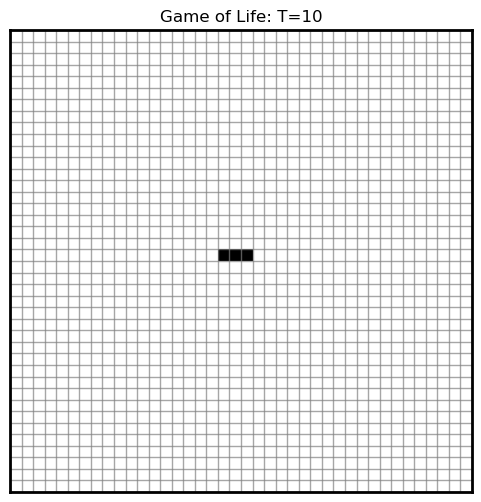

In [12]:
state_history = evolve(length=40, T=10,  config_type='blinker', config_param=0.7, plot=True, InterruptAtConvergence=True)

## Analize data

In this section, we focus on extracting meaningful insights from the Game of Life simulations through data analysis and visualization. By studying the evolution of cellular patterns over time, we can identify key behaviors such as stabilization, oscillations, and chaotic growth.

The `square_distance` function is a tool for measuring the spatial dispersion of living cells in a GoL grid. It quantifies how spread out the active cells are relative to their center of mass, providing insights into the pattern's expansion or stability over time.

In [13]:
def square_distance(grid):
    coordinates = np.argwhere(grid == 1)
    if len(coordinates) > 0:
        center_of_mass = np.mean(coordinates, axis=0)
        distances_squared = np.sum((coordinates - center_of_mass)**2, axis=1)
        return np.mean(distances_squared)
    return 0

The `find_periodicity` function is designed to detect repeating patterns in a sequence of Game of Life states. It determines whether a configuration recurs over time, allowing us to identify oscillators or stable loops within the simulation.

In [14]:
def find_periodicity(states):
    seen_states = {}

    for t, state in enumerate(states):
        # Convert the matrix to a hashable representation
        state_hash = state.tobytes()

        if state_hash in seen_states:
            return t

        seen_states[state_hash] = t

    # No periodicity detected
    return len(states)

The `analyze_base_game_of_life` function performs a detailed analysis of a Game of Life simulation by computing key metrics and generating visualizations. It relies on two helper functions: `square_distance` and `find_periodicity`.

This function does:
 - Tracks the Number of Alive Cells per generation, helping to determine whether the pattern stabilizes, oscillates, or dies out.
 - Computes the Mean Square Distance (R$^2$) to analyze the spatial distribution of live cells.
 - Plots the Initial and Final States of the grid to provide a clear visual comparison.
 - Detects Periodicity to check if the simulation reaches a repeating pattern.
 - Calculates the Average Occupancy Percentage to measure how densely populated the grid remains over time.
 
By combining numerical analysis with visual representations, this function helps identify key behaviors in the Game of Life, such as stabilization, periodic cycles, or chaotic evolution.

In [15]:
def analyze_base_game_of_life(state_history):

    live_cells = [np.sum(current) for current in state_history]
    spread_distances = [square_distance(current) for current in state_history]
    generations = np.arange(len(live_cells))
    total_cells = state_history[0].size

    # Create a figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(8, 7))
    fig.suptitle("Game of Life Analysis", fontsize=16)

    # Subplot 1: Live cell evolution
    ax1 = axes[0, 0]
    ax1.plot(generations, live_cells, label="Alive cells", color='blue')
    ax1.set_title("Time Evolution of Alive Cells")
    ax1.set_xlabel("Generation")
    ax1.set_ylabel("Alive cells")
    ax1.legend()
    ax1.grid()

    # Subplot 2: Mean square distance (R^2)
    if spread_distances is not None:
        ax2 = axes[0, 1]
        ax2.plot(generations, spread_distances, label='$R^2$(t)', color='orange')
        ax2.set_title("Mean Square Distance: $R^2$")
        ax2.set_xlabel("Generation")
        ax2.set_ylabel("$R^2$")
        ax2.legend()
        ax2.grid()
    else:
        axes[0, 1].axis('off')  # Hide this subplot if no data is available

    # Subplot 3: Initial and final states
    ax3 = axes[1, 0]
    ax3.imshow(state_history[0], cmap='binary')
    ax3.axis('off')
    ax3.set_title("First State")

    ax4 = axes[1, 1]
    ax4.imshow(state_history[-1], cmap='binary')
    ax4.axis('off')
    ax4.set_title("Last State")

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit the title

    # Text output
    avg_occupancy = np.mean(live_cells) / total_cells * 100
    print(f"Average Occupancy Percentage: {avg_occupancy:.2f}%")

    # Oscillators
    Period=find_periodicity(state_history)
    print("With", len(state_history), "steps we have a periodicity of", Period)

Average Occupancy Percentage: 0.19%
With 11 steps we have a periodicity of 2


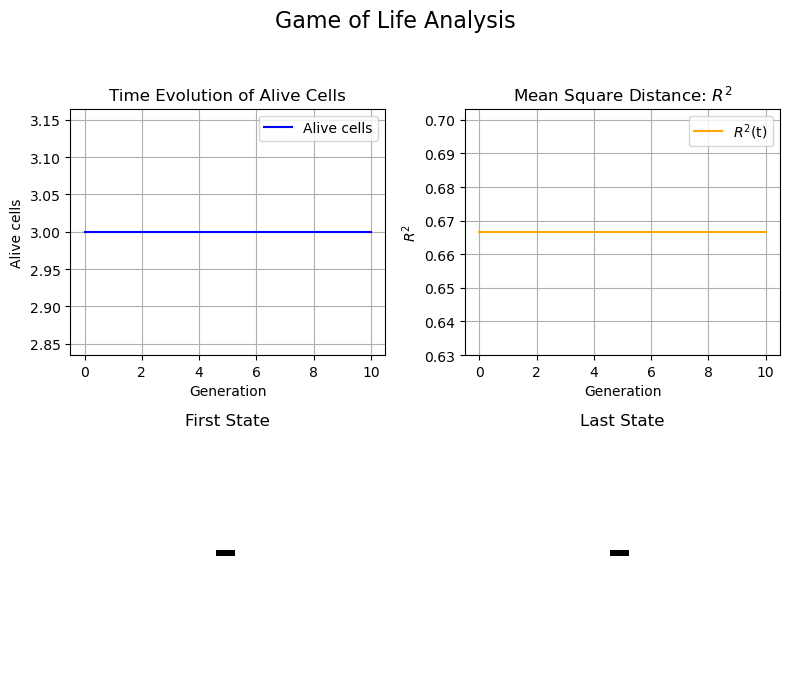

In [16]:
analyze_base_game_of_life(state_history)

###  Simulation of Asymptotic Densities

In [17]:
def simulate_densities(grid_size, T, k, probabilities):
    final_densities = []
    for p in probabilities:
        density_sum = 0
        for _ in range(k):
            state_history = evolve(grid_size, T, config_type='random', config_param=p, plot=False)
            final_matrix = state_history[-1]
            final_density = np.mean(final_matrix)
            density_sum += final_density
        avg_density = density_sum / k
        final_densities.append(avg_density)
    return final_densities

Final densities: [0.0, 0.0015800000000000002, 0.023740000000000004, 0.04240000000000001, 0.04846, 0.053149999999999996, 0.052059999999999995, 0.05021, 0.05938, 0.05474, 0.04838, 0.0505, 0.052039999999999996, 0.04856, 0.051019999999999996, 0.053270000000000005, 0.05519, 0.05518000000000001, 0.05459000000000001, 0.04861, 0.04529999999999999, 0.025880000000000004, 0.021990000000000003, 0.011789999999999998, 0.0006399999999999999, 8e-05, 2.9999999999999997e-05, 0.0, 0.0, 0.0]
Execution time: 0.0 s


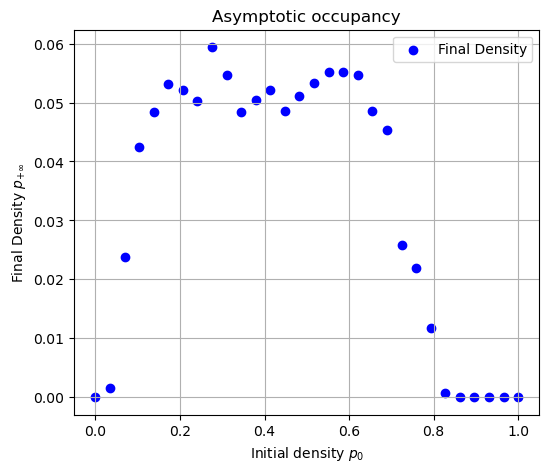

In [18]:
k = 10
T = 500
L = 100
initial_densities = np.linspace(0,1,30)
final_densities = simulate_densities(L, T, k, initial_densities)
t1 = time.time()
print("Final densities:", final_densities)
print("Execution time:", (time.time()-t1), "s")


fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.scatter(initial_densities, final_densities, label="Final Density", color='blue')
ax.set_title("Asymptotic occupancy")
ax.set_xlabel("Initial density $p_0$")
ax.set_ylabel("Final Density $p_{+ \infty}$")
ax.grid()
ax.legend()
plt.show()

### DA SCRIVERE

In [22]:
def simulate_densities_Line(grid_sizes, T, k, probability):
    final_densities = []
    for l in grid_sizes:
        density_sum = 0
        for _ in range(k):
            state_history = evolve(l, T, config_type='random', config_param=probability, plot=False)
            final_matrix = state_history[-1]
            final_density = np.sum(final_matrix)
            density_sum += final_density
        avg_density = density_sum / k
        final_densities.append(avg_density)
    return final_densities

KeyboardInterrupt: 

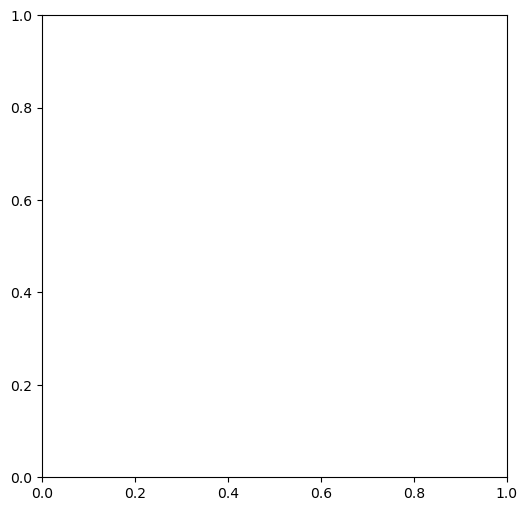

In [23]:
sizes = np.concatenate((np.arange(1,40,10),np.arange(50,600,20)))
final_densities = simulate_densities_Line(sizes, 100, 20, 1/3)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.scatter(sizes, final_densities, label="Final Density", color='blue')
ax.set_title("Middle regime")
ax.set_xlabel("Grid length")
ax.set_ylabel("Final Density $p_{+ \infty}$")
ax.grid()
ax.legend()
plt.show()

### DA SCRIVERE

In [27]:
def simulate_spread(grid_size, T, k, probabilities):
    final_spread = []
    for p in probabilities:
        sum = 0
        for _ in range(k):
            state_history = evolve(grid_size, T, config_type='random', config_param=p, plot=False)
            final_matrix = state_history[-1]
            final_spread = square_distance(final_matrix)
            sum += final_spread
        avg_spread = sum / k
        final_spread.append(avg_spread)
    return final_spread

Final spread: [0.0, 0.008775000000000002, 0.054575000000000005, 0.08732999999999999, 0.08939, 0.09068000000000001, 0.097845, 0.09329499999999999, 0.096365, 0.09436499999999998, 0.09364000000000003, 0.09090000000000001, 0.07366000000000002, 0.050565000000000006, 0.023265, 0.0036649999999999994, 0.00089, 0.0, 0.0, 0.0]


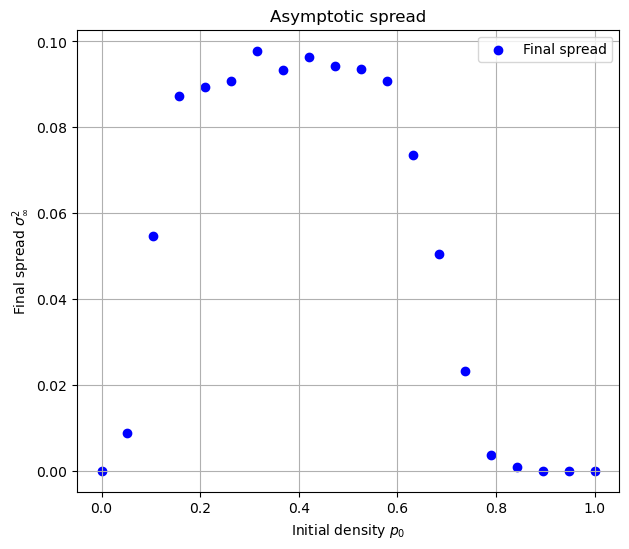

In [29]:
initial_densities = np.linspace(0,1,20)
final_spread = simulate_densities(100, 100, 20, initial_densities)
print("Final spread:",final_spread)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.scatter(initial_densities, final_spread, label="Final spread", color='blue')
ax.set_title("Asymptotic spread")
ax.set_xlabel("Initial density $p_0$")
ax.set_ylabel("Final spread $\sigma_{\infty}^2$")
ax.grid()
ax.legend()
plt.show()

### DA SCRIVERE

In [36]:
def DistPeriodicity(grid_size, T, k, probability=0.5):
    Periods = []
    for i in range(k):
        state_history = evolve(grid_size, T, config_type='random',config_param=probability,plot=False)
        Period = find_periodicity(state_history)
        Periods.append(Period)
    return Periods

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


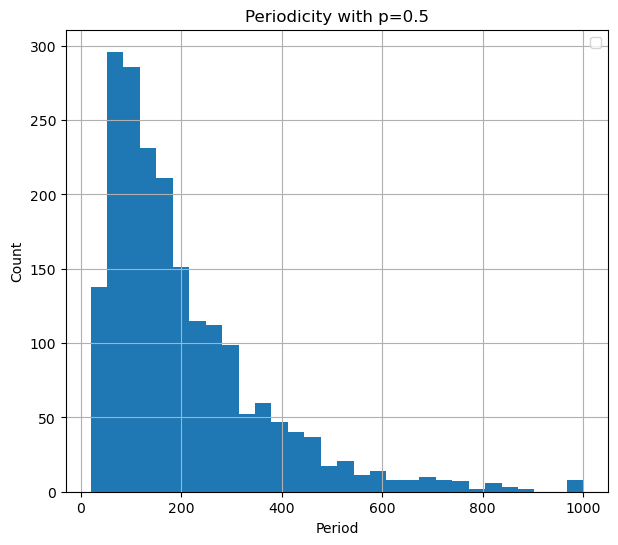

In [37]:
p = 0.5
Periods = DistPeriodicity(20, 1000, 2000, probability=p)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.hist(Periods,bins=30)
ax.set_title("Periodicity with p="+str(p))
ax.set_xlabel("Period")
ax.set_ylabel("Count")
ax.grid()
ax.legend()
plt.show()

In [38]:
def simulate_periodicity(grid_size, T, k, probabilities):
    final_period = []
    for p in probabilities:
        sum = 0
        for _ in range(k):
            state_history = evolve(grid_size, T, config_type='random',config_param=p,plot=False)
            Period=find_periodicity(state_history)
            sum += Period
        avg_period = sum / k
        final_period.append(avg_period)
    return final_period

[0.0, 0.008775000000000002, 0.054575000000000005, 0.08732999999999999, 0.08939, 0.09068000000000001, 0.097845, 0.09329499999999999, 0.096365, 0.09436499999999998, 0.09364000000000003, 0.09090000000000001, 0.07366000000000002, 0.050565000000000006, 0.023265, 0.0036649999999999994, 0.00089, 0.0, 0.0, 0.0]


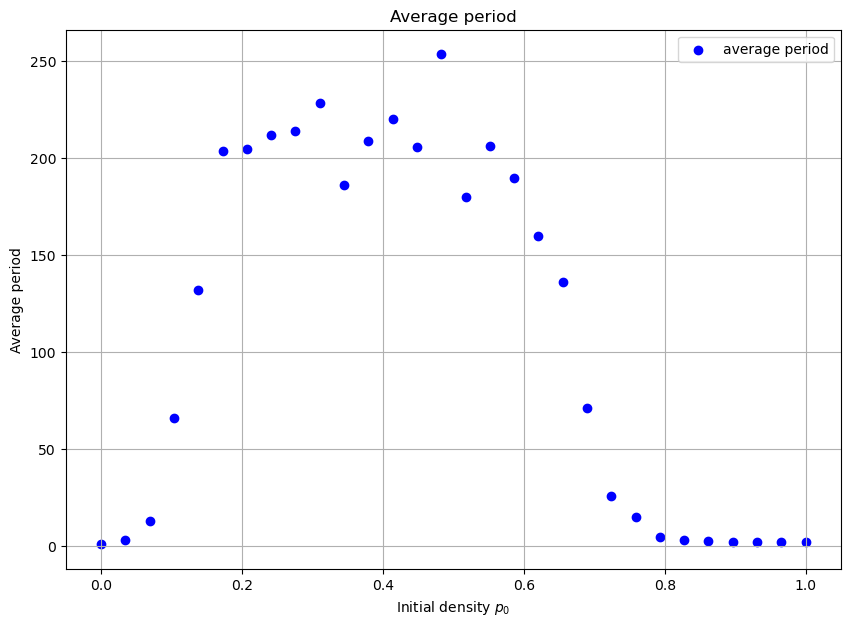

In [39]:
initial_densities = np.linspace(0,1,30)
final_period = simulate_periodicity(20, 1500, 100, initial_densities)
print("Final spread:", final_spread)


fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.scatter(initial_densities, final_period, label="average period", color='blue')
ax.set_title("Average period")
ax.set_xlabel("Initial density $p_0$")
ax.set_ylabel("Average period")
ax.grid()
ax.legend()
plt.show()

In [44]:
def count_pattern_torus(grid, pattern):
    pattern = np.pad(pattern,1)
    rotations = [pattern]
    for _ in range(3):
        rotations.append(np.rot90(rotations[-1]))
    grid_size = grid.shape[0]
    pattern_size1 = pattern.shape[0]
    pattern_size2 = pattern.shape[1]
    count = 0
    for i in range(grid_size):
        for j in range(grid_size):
            subgrid1 = np.array([
            [grid[(i + x) % grid_size, (j + y) % grid_size] for y in range(pattern_size2)]
            for x in range(pattern_size1)
            ])
            subgrid2 = np.array([
            [grid[(i + x) % grid_size, (j + y) % grid_size] for y in range(pattern_size1)]
            for x in range(pattern_size2)
            ])
            if any(np.array_equal(subgrid1, rot) for rot in rotations) or any(np.array_equal(subgrid2, rot) for rot in rotations):
                count += 1
                
    return count

In [49]:
def FindFrequencyPerPattern(lengthGrid, T, k, p, pattern):

    global PatternsName 
    Patterns = [initial_state(lengthGrid, pattern_name=pattern, config_param=0.5, return_Pattern=True) for pattern in PatternsName]
    Frequencies = np.zeros((k, len(PatternsName)))
    for i in range(k):
        if i % int(k/20) == 0:
            print(i/k)
        state_history = evolve(lengthGrid, T, config_type='random', config_param=p, plot=False)
        Counts = np.array([count_pattern_torus(state_history[-1],pattern) for pattern in Patterns])
        Counts = Counts / np.sum(Counts)
        Frequencies[i,:] = Counts.T

    return np.nanmean(Frequencies, axis=0)

0.0


C:\Users\utente\AppData\Local\Temp\ipykernel_8772\4100857896.py:11: RuntimeWarning: invalid value encountered in divide
  Counts = Counts / np.sum(Counts)


0.05
0.1
0.15
0.2
0.25
0.3
0.35
0.4
0.45
0.5
0.55
0.6
0.65
0.7
0.75
0.8
0.85
0.9
0.95


NameError: name 'Expected' is not defined

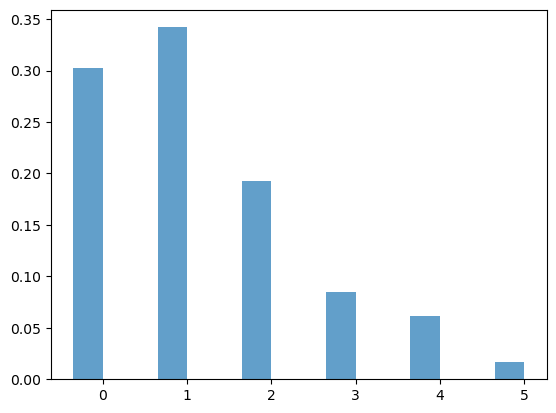

In [50]:
PatternsName = [
    "blinker",
    "block",
    "beehive",
    "loaf",
    "boat",
    "tub"]


Freq = FindFrequencyPerPattern(20, 600, 1000, 0.375, "block")

x = np.arange(len(PatternsName))  # the label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots()

bars1 = ax.bar(x - width/2, Freq, width, label='Freq', alpha=0.7)
bars2 = ax.bar(x + width/2, Expected, width, label='Expected', alpha=0.7)

ax.set_xlabel('Patterns')
ax.set_ylabel('Values')
ax.set_title('Pattern Frequencies on a 15x15 grid')
ax.set_xticks(x)
ax.set_xticklabels(PatternsName)
ax.legend()
plt.show()

### DA SCRIVERE

In [51]:
def calculate_fractal_dimension(grid):
    box_sizes = range(2, grid.shape[0] // 2)
    N_values = []
    for size in box_sizes:
        N = box_count(grid, size)
        N_values.append(N)

    log_box_sizes = np.log(box_sizes)
    log_N_values = np.log(N_values)

    slope, intercept = np.polyfit(log_box_sizes, log_N_values, 1)
    return -slope

def box_count(grid, box_size):
    N = 0
    grid_size = grid.shape[0]
    for i in range(0, grid_size, box_size):
        for j in range(0, grid_size, box_size):
            box = grid[i:i + box_size, j:j + box_size]
            if np.sum(box) > 0:
                N += 1
    return N

def simulate_fractal_dimension(grid_size, T, k, probabilities):
    final_fractal_dimension = []
    for p in probabilities:
        sum_fractal_dimension = 0
        for _ in range(k):
            state_history = evolve(grid_size, T, config_type='random', config_param=p, plot=False, InterruptAtConvergence=True)
            final_state = state_history[-1]
            fractal_dim = calculate_fractal_dimension(final_state)
            sum_fractal_dimension += fractal_dim
        avg_fractal_dim = sum_fractal_dimension / k
        final_fractal_dimension.append(avg_fractal_dim)

    return final_fractal_dimension

In [ ]:
initial_densities = np.linspace(0,1,20)
Final_Dimensions = []
sizes = [50,100,200,400,600]
for size in sizes:
    final_Dimension = simulate_fractal_dimension(size, 500, 10, initial_densities)
    Final_Dimensions.append(final_Dimension)
    
    
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
for i,size in enumerate(sizes):
    ax.plot(initial_densities, Final_Dimensions[i], label="size "+str(size))
ax.set_title("Average Fractal Dimenson at $+\infty$")
ax.set_xlabel("Initial density $p_0$")
ax.set_ylabel("Average Dimension")
ax.grid()
ax.legend()
plt.show()

## Hierarchical Game of Life

In this section, we explore a multi-scale version of Conway's Game of Life, where cellular automata evolve across nested hierarchical levels. Unlike the traditional Game of Life, which operates on a single grid, this hierarchical model introduces multiple layers of cellular structures, influencing each other dynamically.

In [134]:
cmap = mcolors.ListedColormap([(1, 1, 1, 0), (0, 0, 0, 1)])
bounds = [0, 0.5, 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

The `PlotGridNested` function is responsible for visualizing the hierarchical version of Conway’s Game of Life by displaying the grid at different levels of resolution. It overlays fine and coarse gridlines to differentiate between nested structures and dynamically updates the figure for animation-like visualization.

In [135]:
def PlotGridNested(grid, ax, fig,fine_spacing=1, coarse_spacing=1, grid0=None, t=0):
    
    #clear_output(wait=True)
    ax.clear()
    ax.imshow(grid, cmap=cmap, norm=norm, interpolation='nearest', extent=[0, grid.shape[1], 0, grid.shape[0]])

    # Fine gridlines
    ax.set_xticks(np.arange(0, grid.shape[1], fine_spacing), minor=True)
    ax.set_yticks(np.arange(0, grid.shape[0], fine_spacing), minor=True)
    ax.grid(which="minor", color="gray", linestyle='-', linewidth=1, alpha=0.7)

    # Coarse gridlines
    ax.set_xticks(np.arange(0, grid.shape[1], coarse_spacing), minor=False)
    ax.set_yticks(np.arange(0, grid.shape[0], coarse_spacing), minor=False)
    ax.grid(which="major", color="black", linestyle='-', linewidth=2)
    ax.set_title("Conway's Game of Life "+str(t))
    if coarse_spacing != 1:
        ax.imshow(grid0, alpha=0.5, cmap=cmap, norm=norm, interpolation='nearest', extent=[0, grid.shape[1], 0, grid.shape[0]])
        ax.set_title("Inception Game of Life "+str(t))

    # Remove axis ticks
    ax.tick_params(axis='both', which='both', length=0)
    ax.axes.xaxis.set_ticklabels([])
    ax.axes.yaxis.set_ticklabels([])
    ax.set_xlim(0, grid.shape[0])
    ax.set_ylim(0, grid.shape[1])
    #Display in Jupyter Notebook
    clear_output(wait=True)
    time.sleep(0)
    display(fig)

The `majority_rule` function aggregates information from a lower-level grid (`matrixL`) to generate a higher-level representation (`matrixH`). It applies a majority rule by determining whether a region should be considered "alive" or "dead" based on the sum of its values.

In [136]:
def majority_rule(matrixL):
    try:
        matrixH = np.zeros(matrixL.shape[:-2])
    except:
        print(matrixL)
    HalfArea = (matrixL.shape[-1]**2) // 2
    for idx in np.ndindex(matrixH.shape):
        sub_matrix = matrixL[idx]
        total_sum = np.sum(sub_matrix)
        if total_sum > 0:
            matrixH[idx] = 1
        else:
            matrixH[idx] = 0
    return matrixH

The `create_nested_matrices` function generates a hierarchical structure of matrices for the nested Game of Life. It builds a series of grids at different levels, where each level represents a coarser view of the system.

In [137]:
def create_nested_matrices(dimensions, config_param=0.5):
    matrices = []
    previous_shape = [dimensions[0], dimensions[0]]  # The size of the first matrix
    matrices.append(np.random.choice([0,1], p=[1-config_param,config_param], size=previous_shape))
    for i in range(1, len(dimensions)):
        previous_shape = previous_shape + [dimensions[i], dimensions[i]]  # Add (li, li) dimensions
        matrices.append(np.random.randint(2, size=previous_shape))
    Levels = np.arange(len(dimensions))[::-1]
    matrices[-1] = np.random.choice([0,1], p=[1-config_param,config_param], size=matrices[-1].shape)
    for l in Levels[1:]:
        matrices[l] = majority_rule(matrices[l+1])
    return matrices

The `AdvanceMatrix` function propagates the Game of Life rules across all levels, ensuring that each sub-grid evolves independently within the hierarchical structure.

In [138]:
def AdvanceMatrix(MatrixLevel):
    MatrixLevelCopy = MatrixLevel.copy()
    for idx in np.ndindex(MatrixLevel.shape[:-2]):
        sub_GoL = MatrixLevel[idx]
        next_sub_Gol = np.empty_like(sub_GoL)
        next_sub_Gol = NextStep(sub_GoL,next_sub_Gol)
        MatrixLevelCopy[idx] = next_sub_Gol
        if len(MatrixLevel.shape) == 2:
            #print(sub_GoL,next_sub_Gol)
            pass
        #if len(MatrixLevel.shape) == 2:
            #print(MatrixLevel,MatrixLevelCopy)
    return MatrixLevelCopy

The `NextStepNested` function updates a hierarchical Game of Life grid by applying evolution rules across different levels. It processes the system in two phases: "Going Up" (from fine to coarse levels) and "Going Down" (from coarse to fine levels).

In [139]:
def NextStepNested(current, next):
    Levels = np.arange(len(current))[::-1]
  
    # GoingUp
    next[Levels[0]] = AdvanceMatrix(current[Levels[0]])
    for l in Levels[1:]:
        next[l] = majority_rule(next[l+1])
        next[l] = AdvanceMatrix(next[l])

    #GoingDown
    Levels = Levels[::-1]
    for l in Levels[1:]:
        for idx in np.ndindex(next[l-1].shape):
            if current[l-1][idx] == 1 and next[l-1][idx] == 1: #da distinguere da 2 casi: sopravissuto o creato? Fatto
                if np.all(next[l][idx] == 0):
                    next[l][idx]=np.random.choice([0,1], p=[0.5,0.5],size=next[l][idx].shape)
                continue

            if current[l-1][idx] == 1 and next[l-1][idx] == 0:
                next[l][idx]=np.zeros_like(next[l][idx])
                
            if current[l-1][idx] == 0 and next[l-1][idx] == 0:
                continue

            if current[l-1][idx] == 0 and next[l-1][idx] == 1:
                next[l][idx] = np.random.choice([0,1], p=[0.5,0.5], size=next[l][idx].shape)
        #print("dopo",current,next)`
    return next

The `evolve_Nested` function simulates and visualizes a multi-level Game of Life, capturing emergent behaviors across different scales.

In [140]:
def evolve_Nested(lengthList, T, plot=True, config_param=0.5):
    
    # Initialize the universe
    N = len(lengthList)
    Matrices = create_nested_matrices(lengthList, config_param=config_param)
    current = Matrices
    next = [0]*N
    
    fig, ax = plt.subplots(figsize=(6, 6))
    state_history = [current]
    if plot:
        grid = current[1].swapaxes(2,1).reshape(current[1].shape[0] * current[1].shape[2],-1)
        PlotGridNested(grid, ax, fig,coarse_spacing=current[1].shape[-1], grid0=current[0])
    for t in range(1, T+1):
        next = NextStepNested(current, next)
        current, next = next, current
        state_history.append(copy.deepcopy(current))
        if plot:
            grid = current[1].swapaxes(2,1).reshape(current[1].shape[0] * current[1].shape[2],-1)
            PlotGridNested(grid, ax, fig,coarse_spacing=current[1].shape[-1],grid0=current[0],t=t)

    plt.close(fig)
    return state_history

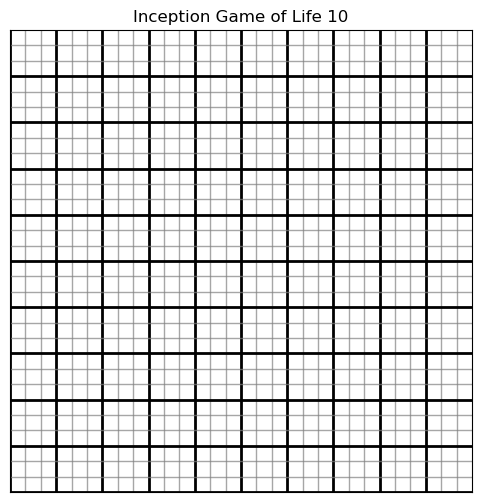

In [141]:
state_history = evolve_Nested([10,3], 10, plot=True, config_param=0.5)

### Simulation of Asymptotic Densities in Nested Game of Life

In this section, we analyze the evolution of the density of active cells in the Hierarchical GoL. Using multiple simulations, we evaluate how the initial density of cells influences their asymptotic occupancy, that is, the final density after a large number of iterations.

The `simulate_densities_Nested` function runs several simulations of the system for different initial density values, calculating the average final densities over multiple trials to obtain statistically significant results.

In [142]:
def simulate_densities_Nested(grid_size, T, k, probabilities):
    final_densities = []
    for p in probabilities:
        density_sum = 0
        for _ in range(k):
            t1=time.time()
            state_history= evolve_Nested(grid_size, T, plot=False, config_param=p)
            final_matrix = state_history[-1][-1]
            final_density = np.mean(final_matrix)
            density_sum += final_density
        avg_density = density_sum / k
        final_densities.append(avg_density)
    return final_densities

Now we simulate the Hierarchical Game of Life for different initial densities of active cells, ranging from 0 to 1. The `simulate_densities_Nested` function is called for each initial density, running the simulation k times for each value and calculating the average final density after T iterations. The execution time is printed, followed by a plot showing the relationship between the initial density and the final density, revealing how the system reaches its steady state over time.

Final densities: [0.0, 0.0, 0.0, 0.0, 0.005333333333333333, 0.008888888888888889, 0.004, 0.005333333333333333, 0.0035555555555555557, 0.008888888888888889, 0.005333333333333333, 0.0017777777777777779, 0.0071111111111111115, 0.004, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Execution time: 2.362561321258545 min


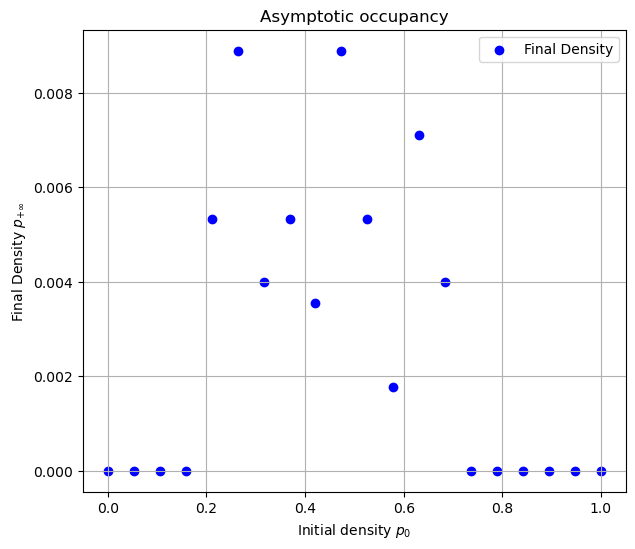

In [133]:
k = 10
T = 100
initial_densities = np.linspace(0,1,20)
t1 = time.time()
final_densities = simulate_densities_Nested([10,3], T, k, initial_densities)
print("Final densities:", final_densities)
print("Execution time:", (time.time()-t1)/60, "min")


fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.scatter(initial_densities, final_densities, label="Final Density", color='blue')
ax.set_title("Asymptotic occupancy")
ax.set_xlabel("Initial density $p_0$")
ax.set_ylabel("Final Density $p_{+ \infty}$")
ax.grid()
ax.legend()
plt.show()